# Preprocessing

We will begin by reformatting our dataset a bit. We will begin by creating a list containing the path to each audio file. This will make it easier to iterate through the dataset in the future. This also gives us easy access to the number of audio files in the dataset, which will allow us to track our progress more easily when processing data. Then we can extract the ground truth values for tempo and beats into more easily readable .csv files using the provided started code (modified slightly to iterate the aforementioned list).


In [1]:
import os
import csv

In [2]:
# Dataset should be placed within a data folder on the same level as this notebook
root = os.path.abspath('./data/ballroom')

# Ballroom dataset inner directories
audio_root = os.path.join(root, "BallroomData")
beats_root = os.path.join(root, "BallroomAnnotations", "ballroomBeats")
tempo_root = os.path.join(root, "BallroomAnnotations", "ballroomTempo")

In [3]:
audio_files = []

# Iterate through the style folders in the dataset
for style in os.listdir(audio_root):
    style_path = os.path.join(audio_root, style)

    if not os.path.isdir(style_path):
        continue

    # Add each audio file's path to the list
    for file in os.listdir(style_path):
        if not file.endswith(".wav"):
            continue

        path = os.path.join(style_path, file)
        audio_files.append(path)

In [4]:
# Create directories to store generated CSV files
beat_out = os.path.join(root, "beat_csv")
tempo_out = os.path.join(root, "tempo_csv")

os.makedirs(beat_out, exist_ok=True)
os.makedirs(tempo_out, exist_ok=True)

curr = 1

# Iterate through all audio files
for file in audio_files:
    filename = os.path.basename(file)
    base = filename.replace(".wav", "")

    bpm_path = os.path.join(tempo_root, base + ".bpm")
    beats_path = os.path.join(beats_root, base + ".beats")

    print(f'File {curr}/{len(audio_files)} - {filename}:')

    # -------------------------
    # TEMPO CSV
    # -------------------------
    if os.path.exists(bpm_path):
        with open(bpm_path) as f:
            bpm = float(f.read().strip())

        tempo_file = os.path.join(tempo_out, base + "_tempo.csv")

        with open(tempo_file, "w", newline="") as f:

            writer = csv.DictWriter(
                f,
                fieldnames=["file", "style", "tempo_bpm"]
            )

            writer.writeheader()
            writer.writerow({
                "file": file,
                "style": style,
                "tempo_bpm": bpm
            })

        print(f'\tTempo CSV - {tempo_file}')

    # -------------------------
    # BEAT CSV
    # -------------------------
    if os.path.exists(beats_path):
        beat_rows = []

        with open(beats_path) as f:

            for line in f:

                parts = line.strip().split()

                beat_time = float(parts[0])
                beat_id = int(parts[1])

                beat_rows.append({
                    "file": file,
                    "style": style,
                    "beat_time": beat_time,
                    "beat_id": beat_id
                })

        beat_file = os.path.join(beat_out, base + "_beats.csv")

        with open(beat_file, "w", newline="") as f:

            writer = csv.DictWriter(
                f,
                fieldnames=["file", "style", "beat_time", "beat_id"]
            )

            writer.writeheader()
            writer.writerows(beat_rows)

        print(f'\tBeat CSV - {beat_file}')

    curr += 1

print("\nPer-file beat and tempo CSVs created.")

	Beat CSV - /Users/aidanmascoli/Documents/Georgia Tech/Spring 2026/MUSI 2526/Projects/Project2/data/ballroom/beat_csv/Media-103708_beats.csv
File 484/698 - Media-105609.wav:
	Tempo CSV - /Users/aidanmascoli/Documents/Georgia Tech/Spring 2026/MUSI 2526/Projects/Project2/data/ballroom/tempo_csv/Media-105609_tempo.csv
	Beat CSV - /Users/aidanmascoli/Documents/Georgia Tech/Spring 2026/MUSI 2526/Projects/Project2/data/ballroom/beat_csv/Media-105609_beats.csv
File 485/698 - Albums-Macumba-07.wav:
	Tempo CSV - /Users/aidanmascoli/Documents/Georgia Tech/Spring 2026/MUSI 2526/Projects/Project2/data/ballroom/tempo_csv/Albums-Macumba-07_tempo.csv
	Beat CSV - /Users/aidanmascoli/Documents/Georgia Tech/Spring 2026/MUSI 2526/Projects/Project2/data/ballroom/beat_csv/Albums-Macumba-07_beats.csv
File 486/698 - Media-103705.wav:
	Tempo CSV - /Users/aidanmascoli/Documents/Georgia Tech/Spring 2026/MUSI 2526/Projects/Project2/data/ballroom/tempo_csv/Media-103705_tempo.csv
	Beat CSV - /Users/aidanmascoli/Do

# Track Metadata
Before we get to analyzing the all of the audio in the dataset, it may be useful to store some metadata for each track, like sample rate, style, length, etc. We can iterate through all our audio files and store all of this in one .csv file.

In [5]:
from scipy.io.wavfile import read

In [6]:
meta_rows = []
for file in audio_files:
    dirname, filename = os.path.split(file)
    (sample_rate, x) = read(file)

    length = x.shape[-1] / sample_rate
    style = dirname.strip('/').split('/')[-1]

    meta_rows.append({
        "file": filename,
        "directory": dirname,
        "style": style,
        "sample rate": sample_rate,
        "length": length
    })

meta_file = os.path.join(root, "metadata.csv")
with open(meta_file, "w", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=["file", "directory", "style", "sample rate", "length"]
    )

    writer.writeheader()
    writer.writerows(meta_rows)

print(f'Metadata CSV written at {meta_file}.')

Metadata CSV written at /Users/aidanmascoli/Documents/Georgia Tech/Spring 2026/MUSI 2526/Projects/Project2/data/ballroom/metadata.csv.


# Novelty Function
We begin the process of Onset Detection and Tempo Estimation by creating a novelty function from our audios. This novelty function is calculated by taking the derivative of the RMSE of each audio file. We can save our novelty functions for later use as .npy files in a new directory. We will begin by globally defining our frame size and hop length.

In [7]:
HOP_LENGTH = 512
FRAME_LENGTH = 1024

Next, we will define a function to extract novelty from an audio signal.

In [11]:
import librosa
import numpy as np

def novelty(x, hop_length, frame_length):
    # Convert multi-channel audio to mono
    if len(x.shape) > 1:
        x = x.sum(axis=0)

    # Normalize audio signal
    x_norm = x / max(abs(x))

    # Calculate novelty function
    rmse = librosa.feature.rms(y=x_norm, frame_length=frame_length, hop_length=hop_length)
    rmse_diff = np.diff(rmse[0])
    novelty = np.concatenate((rmse_diff, np.array([0])))  # Add a zero at the end to maintain the same length
    novelty[novelty < 0] = 0  # We only care about increases in energy

    return novelty

Let's plot the novelty for one of the audio files as a quick sanity check.

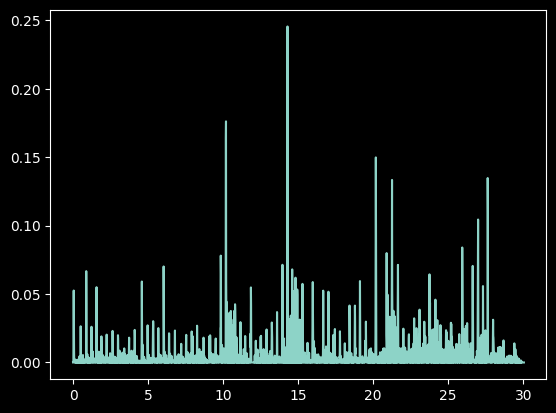

In [23]:
import matplotlib.pyplot as plt

(fs, x) = read(os.path.abspath(audio_files[99]))  # load sample from dataset
n = novelty(x, HOP_LENGTH, FRAME_LENGTH)

# calculate time axis for plot
frames=range(len(n))
t = librosa.frames_to_time(frames, sr=fs, hop_length=HOP_LENGTH)

plt.plot(t, n)

Let's also listen to the audio to see if the novelty functon seems to match.

In [24]:
from IPython.display import Audio

Audio(x, rate=fs)

Finally, we can generate this novelty function for all audios in the dataset.

In [25]:
# Make directory for novelty functions
novelty_dir = os.path.join(root, 'novelty')
os.makedirs(novelty_dir, exist_ok=True)

done = 0
for file in audio_files:
    basename = os.path.basename(file)
    (fs, x) = read(file)
    n = novelty(x, HOP_LENGTH, FRAME_LENGTH)

    filename = basename.replace(".wav", ".npy")
    with open(os.path.join(novelty_dir, filename), 'wb') as f:
        np.save(f, n)

    done += 1
    print(f'[{done}/{len(audio_files)}] Completed file "{basename}" - novelty saved as "{filename}"')

[696/698] Completed file "Media-106009.wav" - novelty saved as "Media-106009.npy"
[697/698] Completed file "Albums-Cafe_Paradiso-12.wav" - novelty saved as "Albums-Cafe_Paradiso-12.npy"
[698/698] Completed file "Albums-Latin_Jam3-07.wav" - novelty saved as "Albums-Latin_Jam3-07.npy"
